In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [119]:
df = pd.read_csv("../extraction/caregiverRaw.csv", sep=";")

df

,genderId,id,orgRef,dateOfBirth,nationality,maritalStatus,preferredTransport,Betreuer:innen_Bew_Ein_Ja,bew-am,eingestellt-am,...,gewerbeschein_nr,isPaymentBlocked,allgemeine-erfahrung-ausland-dauer,covid-1-wann,covid-2-wann,erfahrung-krankenhaus-abteilung,allgemeine-taetigkeiten-ausland,grund-unpassend,weitere_ausbildungen,fachspezifische-ausbildung-welche
0,F,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,Direktbewerbung,19950804,Rumänien,Verheiratet,Sonstiges,False,2.019071e+13,20190903020000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F,002e16cc-274f-bf74-d123-98b4704b1aab,Team Rumänien,19810731,Rumänien,Verheiratet,Blagoiescu,False,2.025013e+13,20250206010000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F,00411252-62ff-bc52-5ab0-5fbfd476b2a2,Team Rumänien,19710127,Rumänien,Verwitwet,Blagoiescu,False,2.025101e+13,20251016020000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F,004afdff-fff7-9d87-63ae-7273409908bb,ZZ_Palaloga rum.,19680328,Österreich,Geschieden,ZZ_Cotrans,False,2.020013e+13,20200213010000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F,0061dab5-0194-a1a8-5aba-d718f21e2ff7,ZZ_PML Übernahme,19660517,Slowakei,Verwitwet,Selbstfahrer,False,2.022100e+13,20221001020000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7366,F,ffddabef-72ea-967e-dc01-c9edbb211fb7,Team Rumänien,19700303,Rumänien,Ledig,Master Express,False,2.023042e+13,20230425020000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7367,F,ffdde431-8a90-7beb-4330-a7956fb650aa,ZZ_Palaloga rum.,19800428,Rumänien,Ledig,Blagoiescu,False,2.020081e+13,20200818020000,...,NaN,False,NaN,2.021122e+13,2.021122e+13,NaN,NaN,NaN,NaN,NaN
7368,F,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,Direktbewerbung,19640207,Rumänien,Verheiratet,Master Express,False,2.018101e+13,20181023020000,...,NaN,False,NaN,2.021051e+13,2.021051e+13,NaN,NaN,NaN,NaN,NaN
7369,F,ffe47fdd-10cb-ff7b-5190-85f5fff12bd0,Team Ungarn,19681129,Ungarn,Ledig,Selbstfahrer,False,2.019101e+13,20191112010000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
def eda_summary(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "count": df.count(),
        "missing": df.isna().sum(),
        "missing_%": df.isna().mean() * 100,
        "unique": df.nunique(dropna=True),
    })

    summary["min"] = df.select_dtypes(include="number").min()
    summary["mean"] = df.select_dtypes(include="number").mean()
    summary["median"] = df.select_dtypes(include="number").median()
    summary["max"] = df.select_dtypes(include="number").max()

    return summary.round(2)

summary = eda_summary(df)
summary.to_csv("summary.csv", sep=";")

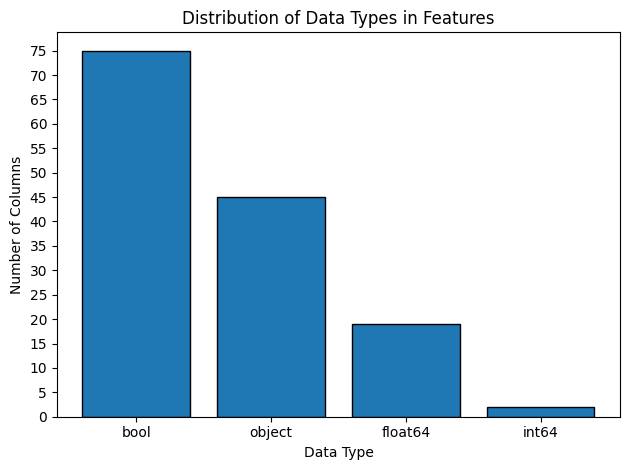

In [121]:
dtypes = summary["dtype"].astype(str).value_counts()

plt.bar(
    dtypes.index,
    dtypes.values,
    edgecolor="black"
)

plt.title("Distribution of Data Types in Features")
plt.xlabel("Data Type")
plt.ylabel("Number of Columns")

plt.yticks(
    np.arange(0, dtypes.max() + 5, 5)
)

plt.tight_layout()
plt.show()

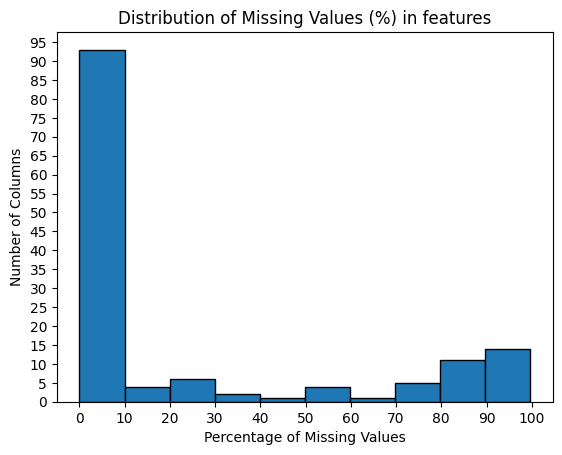

In [122]:
plt.hist(summary["missing_%"], bins=10, edgecolor='black')
plt.title("Distribution of Missing Values (%) in features")
plt.xlabel("Percentage of Missing Values")
plt.ylabel("Number of Columns")
plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 100, 5))
plt.show()

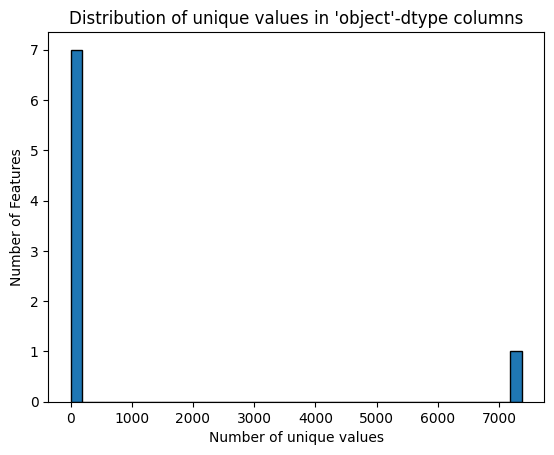

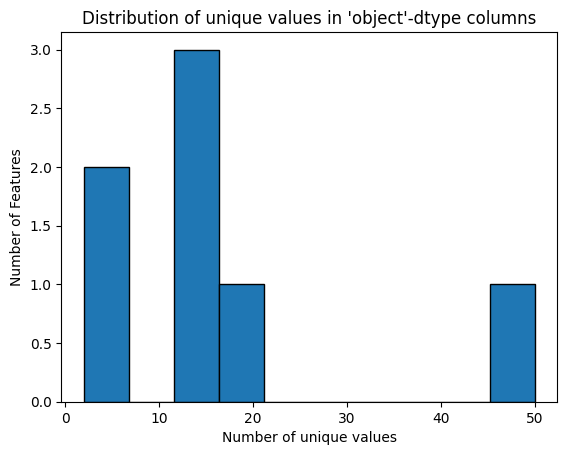

In [123]:


plt.hist(summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object")]["unique"], bins=40, edgecolor='black')
plt.title("Distribution of unique values in 'object'-dtype columns")
plt.xlabel("Number of unique values")
plt.ylabel("Number of Features")

plt.show()

plt.hist(summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object") & (summary["unique"] <= 100)]["unique"], bins=10, edgecolor='black')
plt.title("Distribution of unique values in 'object'-dtype columns")
plt.xlabel("Number of unique values")
plt.ylabel("Number of Features")
plt.show()

In [124]:
summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object") & (summary["unique"] <= 100)]

,dtype,count,missing,missing_%,unique,min,mean,median,max
genderId,object,7371,0,0.00,2,NaN,NaN,NaN,NaN
orgRef,object,7371,0,0.00,50,NaN,NaN,NaN,NaN
nationality,object,7371,0,0.00,16,NaN,NaN,NaN,NaN
preferredTransport,object,7065,306,4.15,18,NaN,NaN,NaN,NaN
pers-dat-sprach-mutt,object,7270,101,1.37,14,NaN,NaN,NaN,NaN
admin-betr-gsber,object,7371,0,0.00,5,NaN,NaN,NaN,NaN
pflegestatus-paket,object,6754,617,8.37,12,NaN,NaN,NaN,NaN


In [125]:
df["orgRef"].value_counts()

orgRef
Sonstiges                     1420
Team Rumänien                 1236
Team Ungarn                    780
ZZ_Palaloga rum.               505
Team Bulgarien                 479
Direktbewerbung                379
Lescan Daniel                  294
Team Ukraine                   219
Pflege aktiv 24                190
Miljenovic Jasna               181
ZZ_ISL Übernahme               159
Team Slowakei                  151
Petrovcinova Danka             145
HC24 Übernahme                 144
ZZ_Fartunova bulg.             138
Vasilescu Heidi                126
IVA Übernahme                  119
ZZ_PML Übernahme                83
ZZ_Rodlauer Übernahme           83
Banuc rum.                      61
Senecura Übernahme              55
ZZ_Dobanici rum.                46
ZZ_Leshtakova bulg.             41
Pflegegruppe Übernahme          40
Sensivita Übernahme             36
ZZ_Tomek pol.                   34
ZZ_Marzena Belkameh             32
ZZ-_Alexan rum.                 26
ZZ_Second Lif

In [126]:
df[summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object") & (summary["unique"] <= 25)].index]

,genderId,nationality,preferredTransport,pers-dat-sprach-mutt,admin-betr-gsber,pflegestatus-paket
0,F,Rumänien,Sonstiges,Rumänisch,CD24,ZZ_Pflegerin
1,F,Rumänien,Blagoiescu,Rumänisch,CD24,Diplomierte Fachkraft
2,F,Rumänien,Blagoiescu,Rumänisch,CD24,Klassik
3,F,Österreich,ZZ_Cotrans,Rumänisch,CD24,Klassik
4,F,Slowakei,Selbstfahrer,Slowakisch,Geschäftsbereich PML,Premium
...,...,...,...,...,...,...
7366,F,Rumänien,Master Express,Rumänisch,CD24,Basis
7367,F,Rumänien,Blagoiescu,Rumänisch,CD24,CD Perle
7368,F,Rumänien,Master Express,Ungarisch,CD24,Premium
7369,F,Ungarn,Selbstfahrer,Ungarisch,CD24,NaN


In [127]:
pflege_map = {
    "ZZ_Pflegerin": 60,
    "Diplomierte Fachkraft": 130,
    "Klassik": 90,
    "Premium": 95,
    "ZZ_Standard Plus": 82,
    "Basis": 69,
    "Palliativbegleitung": 100,
    "CD Perle": 89,
    "Demenzbetreuung": 95,
    "ZZ_Pflege leicht": 59,
    "ZZ_Springerin": 69,
    "CD Perle Plus": 125,
}

average = sum(pflege_map.values()) / len(pflege_map)

In [128]:
df["pflegestatus-paket"] = (
    df["pflegestatus-paket"]
    .map(pflege_map)
    .fillna(average)
)

In [129]:
df["pflegestatus-paket"].unique()

array([ 60.        , 130.        ,  90.        ,  95.        ,
        82.        ,  88.58333333,  69.        , 100.        ,
        89.        ,  59.        , 125.        ])

In [130]:
counts = df["orgRef"].value_counts()

df.loc[
    df["orgRef"].map(counts) < 100,
    "orgRef"
] = "Other"


# 2. Group values containing "Übernahme"
df.loc[
    df["orgRef"].str.contains("Übernahme", case=False, na=False),
    "orgRef"
] = "Takeover"


# 3. Group values containing "ZZ"
df.loc[
    df["orgRef"].str.contains("ZZ", case=False, na=False),
    "orgRef"
] = "Former"

df.loc[
    df["orgRef"] == "Sonstiges",
    "orgRef"
] = "Other"

In [131]:
df["orgRef"].value_counts()

orgRef
Other                 2126
Team Rumänien         1236
Team Ungarn            780
Former                 643
Team Bulgarien         479
Takeover               422
Direktbewerbung        379
Lescan Daniel          294
Team Ukraine           219
Pflege aktiv 24        190
Miljenovic Jasna       181
Team Slowakei          151
Petrovcinova Danka     145
Vasilescu Heidi        126
Name: count, dtype: int64

In [132]:
columns_to_encode = [
    "genderId",
	"nationality",
	"preferredTransport",
	"pers-dat-sprach-mutt",
	"admin-betr-gsber",
	"orgRef"
]

df = pd.get_dummies(
    df,
    columns=columns_to_encode,
    dtype=int,
	drop_first=True
)

In [133]:
df

,id,dateOfBirth,maritalStatus,Betreuer:innen_Bew_Ein_Ja,bew-am,eingestellt-am,einstellvor,istangest,macht-stundenpak,empfohlen-von,...,orgRef_Other,orgRef_Petrovcinova Danka,orgRef_Pflege aktiv 24,orgRef_Takeover,orgRef_Team Bulgarien,orgRef_Team Rumänien,orgRef_Team Slowakei,orgRef_Team Ukraine,orgRef_Team Ungarn,orgRef_Vasilescu Heidi
0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,19950804,Verheiratet,False,2.019071e+13,20190903020000,Deutsch geprüft,True,False,Internet,...,0,0,0,0,0,0,0,0,0,0
1,002e16cc-274f-bf74-d123-98b4704b1aab,19810731,Verheiratet,False,2.025013e+13,20250206010000,NaN,True,True,Facebook,...,0,0,0,0,0,1,0,0,0,0
2,00411252-62ff-bc52-5ab0-5fbfd476b2a2,19710127,Verwitwet,False,2.025101e+13,20251016020000,NaN,True,True,Call now,...,0,0,0,0,0,1,0,0,0,0
3,004afdff-fff7-9d87-63ae-7273409908bb,19680328,Geschieden,False,2.020013e+13,20200213010000,Deutsch geprüft,True,True,Palaloga rum.,...,0,0,0,0,0,0,0,0,0,0
4,0061dab5-0194-a1a8-5aba-d718f21e2ff7,19660517,Verwitwet,False,2.022100e+13,20221001020000,NaN,True,True,NaN,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7366,ffddabef-72ea-967e-dc01-c9edbb211fb7,19700303,Ledig,False,2.023042e+13,20230425020000,NaN,True,True,Larisa Alexan,...,0,0,0,0,0,1,0,0,0,0
7367,ffdde431-8a90-7beb-4330-a7956fb650aa,19800428,Ledig,False,2.020081e+13,20200818020000,Deutsch geprüft,True,True,Palaloga rum.,...,0,0,0,0,0,0,0,0,0,0
7368,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,19640207,Verheiratet,False,2.018101e+13,20181023020000,NaN,True,False,Toth Olga,...,0,0,0,0,0,0,0,0,0,0
7369,ffe47fdd-10cb-ff7b-5190-85f5fff12bd0,19681129,Ledig,False,2.019101e+13,20191112010000,NaN,False,False,rüchherin,...,0,0,0,0,0,0,0,0,1,0


In [134]:
exceptions = [
    "eingestellt-am",
    "ausgesch-am"
]

colsToDrop = [
    col
    for col in summary[summary["missing_%"] > 10].index
    if col not in exceptions
]

df_dropped = df.drop(columns=colsToDrop)

In [135]:
exceptions = [
    "ausgesch-am"
]

cols_to_check = df_dropped.columns.difference(exceptions)

df_dropped = df_dropped.dropna(subset=cols_to_check)

In [136]:
df_dropped

,id,dateOfBirth,Betreuer:innen_Bew_Ein_Ja,eingestellt-am,istangest,macht-stundenpak,ausgesch-am,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,...,orgRef_Other,orgRef_Petrovcinova Danka,orgRef_Pflege aktiv 24,orgRef_Takeover,orgRef_Team Bulgarien,orgRef_Team Rumänien,orgRef_Team Slowakei,orgRef_Team Ukraine,orgRef_Team Ungarn,orgRef_Vasilescu Heidi
0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,19950804,False,20190903020000,True,False,2.025042e+13,True,True,False,...,0,0,0,0,0,0,0,0,0,0
2,00411252-62ff-bc52-5ab0-5fbfd476b2a2,19710127,False,20251016020000,True,True,2.025111e+13,True,True,True,...,0,0,0,0,0,1,0,0,0,0
3,004afdff-fff7-9d87-63ae-7273409908bb,19680328,False,20200213010000,True,True,2.020031e+13,True,True,False,...,0,0,0,0,0,0,0,0,0,0
4,0061dab5-0194-a1a8-5aba-d718f21e2ff7,19660517,False,20221001020000,True,True,2.023031e+13,True,True,True,...,1,0,0,0,0,0,0,0,0,0
5,006e3125-8abb-6cee-fcc0-e17c52ce84b4,19770821,False,20211103010000,True,True,2.021120e+13,True,True,False,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7365,ffdbb7d5-a94f-d177-4495-069e1692c3e4,19720820,False,20231228010000,True,True,NaN,True,True,True,...,0,0,0,0,0,1,0,0,0,0
7366,ffddabef-72ea-967e-dc01-c9edbb211fb7,19700303,False,20230425020000,True,True,2.026033e+13,True,True,False,...,0,0,0,0,0,1,0,0,0,0
7367,ffdde431-8a90-7beb-4330-a7956fb650aa,19800428,False,20200818020000,True,True,NaN,True,True,True,...,0,0,0,0,0,0,0,0,0,0
7368,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,19640207,False,20181023020000,True,False,2.025111e+13,True,True,False,...,0,0,0,0,0,0,0,0,0,0


In [137]:

df_dropped["eingestellt-am"] = pd.to_datetime(
    df_dropped["eingestellt-am"].astype("string"),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

df_dropped["ausgesch-am"] = pd.to_datetime(
    df_dropped["ausgesch-am"].astype("Int64").astype("string"),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)


In [138]:
df_y = df_dropped

df_y

,id,dateOfBirth,Betreuer:innen_Bew_Ein_Ja,eingestellt-am,istangest,macht-stundenpak,ausgesch-am,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,...,orgRef_Other,orgRef_Petrovcinova Danka,orgRef_Pflege aktiv 24,orgRef_Takeover,orgRef_Team Bulgarien,orgRef_Team Rumänien,orgRef_Team Slowakei,orgRef_Team Ukraine,orgRef_Team Ungarn,orgRef_Vasilescu Heidi
0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,19950804,False,2019-09-03 02:00:00,True,False,2025-04-23,True,True,False,...,0,0,0,0,0,0,0,0,0,0
2,00411252-62ff-bc52-5ab0-5fbfd476b2a2,19710127,False,2025-10-16 02:00:00,True,True,2025-11-13,True,True,True,...,0,0,0,0,0,1,0,0,0,0
3,004afdff-fff7-9d87-63ae-7273409908bb,19680328,False,2020-02-13 01:00:00,True,True,2020-03-10,True,True,False,...,0,0,0,0,0,0,0,0,0,0
4,0061dab5-0194-a1a8-5aba-d718f21e2ff7,19660517,False,2022-10-01 02:00:00,True,True,2023-03-07,True,True,True,...,1,0,0,0,0,0,0,0,0,0
5,006e3125-8abb-6cee-fcc0-e17c52ce84b4,19770821,False,2021-11-03 01:00:00,True,True,2021-12-01,True,True,False,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7365,ffdbb7d5-a94f-d177-4495-069e1692c3e4,19720820,False,2023-12-28 01:00:00,True,True,NaT,True,True,True,...,0,0,0,0,0,1,0,0,0,0
7366,ffddabef-72ea-967e-dc01-c9edbb211fb7,19700303,False,2023-04-25 02:00:00,True,True,2026-03-31,True,True,False,...,0,0,0,0,0,1,0,0,0,0
7367,ffdde431-8a90-7beb-4330-a7956fb650aa,19800428,False,2020-08-18 02:00:00,True,True,NaT,True,True,True,...,0,0,0,0,0,0,0,0,0,0
7368,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,19640207,False,2018-10-23 02:00:00,True,False,2025-11-06,True,True,False,...,0,0,0,0,0,0,0,0,0,0


                                  nunique  most_common_pct
Gewerbe_ruhend_Ja                       1       100.000000
Betreuer:innen_Bew_Ein_Ja               1       100.000000
e-zigarette                             1       100.000000
pers-dat-sprach-mutt_Italienisch        2        99.984561
Betreuer:innen_Austritt_Ja              2        99.984561
...                                   ...              ...
pers-koerper-groesse                  114        14.327621
pers-koerper-gewicht                  111         9.495137
eingestellt-am                       1745         1.080747
dateOfBirth                          5097         0.077196
id                                   6477         0.015439

[151 rows x 2 columns]


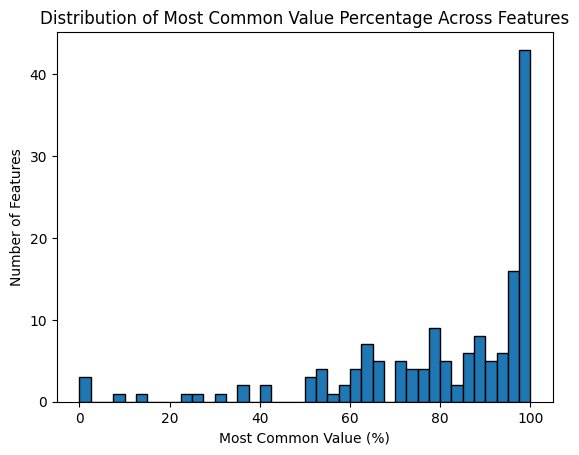

In [139]:
feature_summary = pd.DataFrame({
    "nunique": df_y.nunique(),
    "most_common_pct": df_y.apply(
        lambda col: col.value_counts(normalize=True, dropna=False).iloc[0] * 100
    )
})

print(feature_summary.sort_values("most_common_pct", ascending=False))

plt.hist(feature_summary["most_common_pct"], bins= 40, edgecolor="black")
plt.title("Distribution of Most Common Value Percentage Across Features")
plt.xlabel("Most Common Value (%)")
plt.ylabel("Number of Features")
plt.show()

In [140]:
df_y["dateOfBirth"] = pd.to_datetime(
    df_y["dateOfBirth"].astype("Int64").astype("string"),
    format="%Y%m%d",
    errors="coerce"
)

df_y["birthYear"] = df_y["dateOfBirth"].dt.year
df_y["birthMonth"] = df_y["dateOfBirth"].dt.month



df_y

,id,dateOfBirth,Betreuer:innen_Bew_Ein_Ja,eingestellt-am,istangest,macht-stundenpak,ausgesch-am,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,...,orgRef_Pflege aktiv 24,orgRef_Takeover,orgRef_Team Bulgarien,orgRef_Team Rumänien,orgRef_Team Slowakei,orgRef_Team Ukraine,orgRef_Team Ungarn,orgRef_Vasilescu Heidi,birthYear,birthMonth
0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,1995-08-04,False,2019-09-03 02:00:00,True,False,2025-04-23,True,True,False,...,0,0,0,0,0,0,0,0,1995,8
2,00411252-62ff-bc52-5ab0-5fbfd476b2a2,1971-01-27,False,2025-10-16 02:00:00,True,True,2025-11-13,True,True,True,...,0,0,0,1,0,0,0,0,1971,1
3,004afdff-fff7-9d87-63ae-7273409908bb,1968-03-28,False,2020-02-13 01:00:00,True,True,2020-03-10,True,True,False,...,0,0,0,0,0,0,0,0,1968,3
4,0061dab5-0194-a1a8-5aba-d718f21e2ff7,1966-05-17,False,2022-10-01 02:00:00,True,True,2023-03-07,True,True,True,...,0,0,0,0,0,0,0,0,1966,5
5,006e3125-8abb-6cee-fcc0-e17c52ce84b4,1977-08-21,False,2021-11-03 01:00:00,True,True,2021-12-01,True,True,False,...,0,0,0,1,0,0,0,0,1977,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7365,ffdbb7d5-a94f-d177-4495-069e1692c3e4,1972-08-20,False,2023-12-28 01:00:00,True,True,NaT,True,True,True,...,0,0,0,1,0,0,0,0,1972,8
7366,ffddabef-72ea-967e-dc01-c9edbb211fb7,1970-03-03,False,2023-04-25 02:00:00,True,True,2026-03-31,True,True,False,...,0,0,0,1,0,0,0,0,1970,3
7367,ffdde431-8a90-7beb-4330-a7956fb650aa,1980-04-28,False,2020-08-18 02:00:00,True,True,NaT,True,True,True,...,0,0,0,0,0,0,0,0,1980,4
7368,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,1964-02-07,False,2018-10-23 02:00:00,True,False,2025-11-06,True,True,False,...,0,0,0,0,0,0,0,0,1964,2


In [141]:
df_y.drop(columns="dateOfBirth", inplace=True)

In [142]:
df_y

,id,Betreuer:innen_Bew_Ein_Ja,eingestellt-am,istangest,macht-stundenpak,ausgesch-am,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,oesterreich-gueltig,...,orgRef_Pflege aktiv 24,orgRef_Takeover,orgRef_Team Bulgarien,orgRef_Team Rumänien,orgRef_Team Slowakei,orgRef_Team Ukraine,orgRef_Team Ungarn,orgRef_Vasilescu Heidi,birthYear,birthMonth
0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,False,2019-09-03 02:00:00,True,False,2025-04-23,True,True,False,False,...,0,0,0,0,0,0,0,0,1995,8
2,00411252-62ff-bc52-5ab0-5fbfd476b2a2,False,2025-10-16 02:00:00,True,True,2025-11-13,True,True,True,True,...,0,0,0,1,0,0,0,0,1971,1
3,004afdff-fff7-9d87-63ae-7273409908bb,False,2020-02-13 01:00:00,True,True,2020-03-10,True,True,False,True,...,0,0,0,0,0,0,0,0,1968,3
4,0061dab5-0194-a1a8-5aba-d718f21e2ff7,False,2022-10-01 02:00:00,True,True,2023-03-07,True,True,True,True,...,0,0,0,0,0,0,0,0,1966,5
5,006e3125-8abb-6cee-fcc0-e17c52ce84b4,False,2021-11-03 01:00:00,True,True,2021-12-01,True,True,False,False,...,0,0,0,1,0,0,0,0,1977,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7365,ffdbb7d5-a94f-d177-4495-069e1692c3e4,False,2023-12-28 01:00:00,True,True,NaT,True,True,True,True,...,0,0,0,1,0,0,0,0,1972,8
7366,ffddabef-72ea-967e-dc01-c9edbb211fb7,False,2023-04-25 02:00:00,True,True,2026-03-31,True,True,False,True,...,0,0,0,1,0,0,0,0,1970,3
7367,ffdde431-8a90-7beb-4330-a7956fb650aa,False,2020-08-18 02:00:00,True,True,NaT,True,True,True,True,...,0,0,0,0,0,0,0,0,1980,4
7368,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,False,2018-10-23 02:00:00,True,False,2025-11-06,True,True,False,True,...,0,0,0,0,0,0,0,0,1964,2


In [143]:
exceptions = [
    "eingestellt-am",
    "ausgesch-am",
    "aussch-grund"
]

df_final = df_y.drop(columns=feature_summary[feature_summary["most_common_pct"] > 99].index)

In [144]:
df_final

,id,eingestellt-am,istangest,macht-stundenpak,ausgesch-am,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,oesterreich-gueltig,Kinder_Ja,...,orgRef_Pflege aktiv 24,orgRef_Takeover,orgRef_Team Bulgarien,orgRef_Team Rumänien,orgRef_Team Slowakei,orgRef_Team Ukraine,orgRef_Team Ungarn,orgRef_Vasilescu Heidi,birthYear,birthMonth
0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,2019-09-03 02:00:00,True,False,2025-04-23,True,True,False,False,True,...,0,0,0,0,0,0,0,0,1995,8
2,00411252-62ff-bc52-5ab0-5fbfd476b2a2,2025-10-16 02:00:00,True,True,2025-11-13,True,True,True,True,True,...,0,0,0,1,0,0,0,0,1971,1
3,004afdff-fff7-9d87-63ae-7273409908bb,2020-02-13 01:00:00,True,True,2020-03-10,True,True,False,True,False,...,0,0,0,0,0,0,0,0,1968,3
4,0061dab5-0194-a1a8-5aba-d718f21e2ff7,2022-10-01 02:00:00,True,True,2023-03-07,True,True,True,True,True,...,0,0,0,0,0,0,0,0,1966,5
5,006e3125-8abb-6cee-fcc0-e17c52ce84b4,2021-11-03 01:00:00,True,True,2021-12-01,True,True,False,False,False,...,0,0,0,1,0,0,0,0,1977,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7365,ffdbb7d5-a94f-d177-4495-069e1692c3e4,2023-12-28 01:00:00,True,True,NaT,True,True,True,True,False,...,0,0,0,1,0,0,0,0,1972,8
7366,ffddabef-72ea-967e-dc01-c9edbb211fb7,2023-04-25 02:00:00,True,True,2026-03-31,True,True,False,True,True,...,0,0,0,1,0,0,0,0,1970,3
7367,ffdde431-8a90-7beb-4330-a7956fb650aa,2020-08-18 02:00:00,True,True,NaT,True,True,True,True,False,...,0,0,0,0,0,0,0,0,1980,4
7368,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,2018-10-23 02:00:00,True,False,2025-11-06,True,True,False,True,True,...,0,0,0,0,0,0,0,0,1964,2


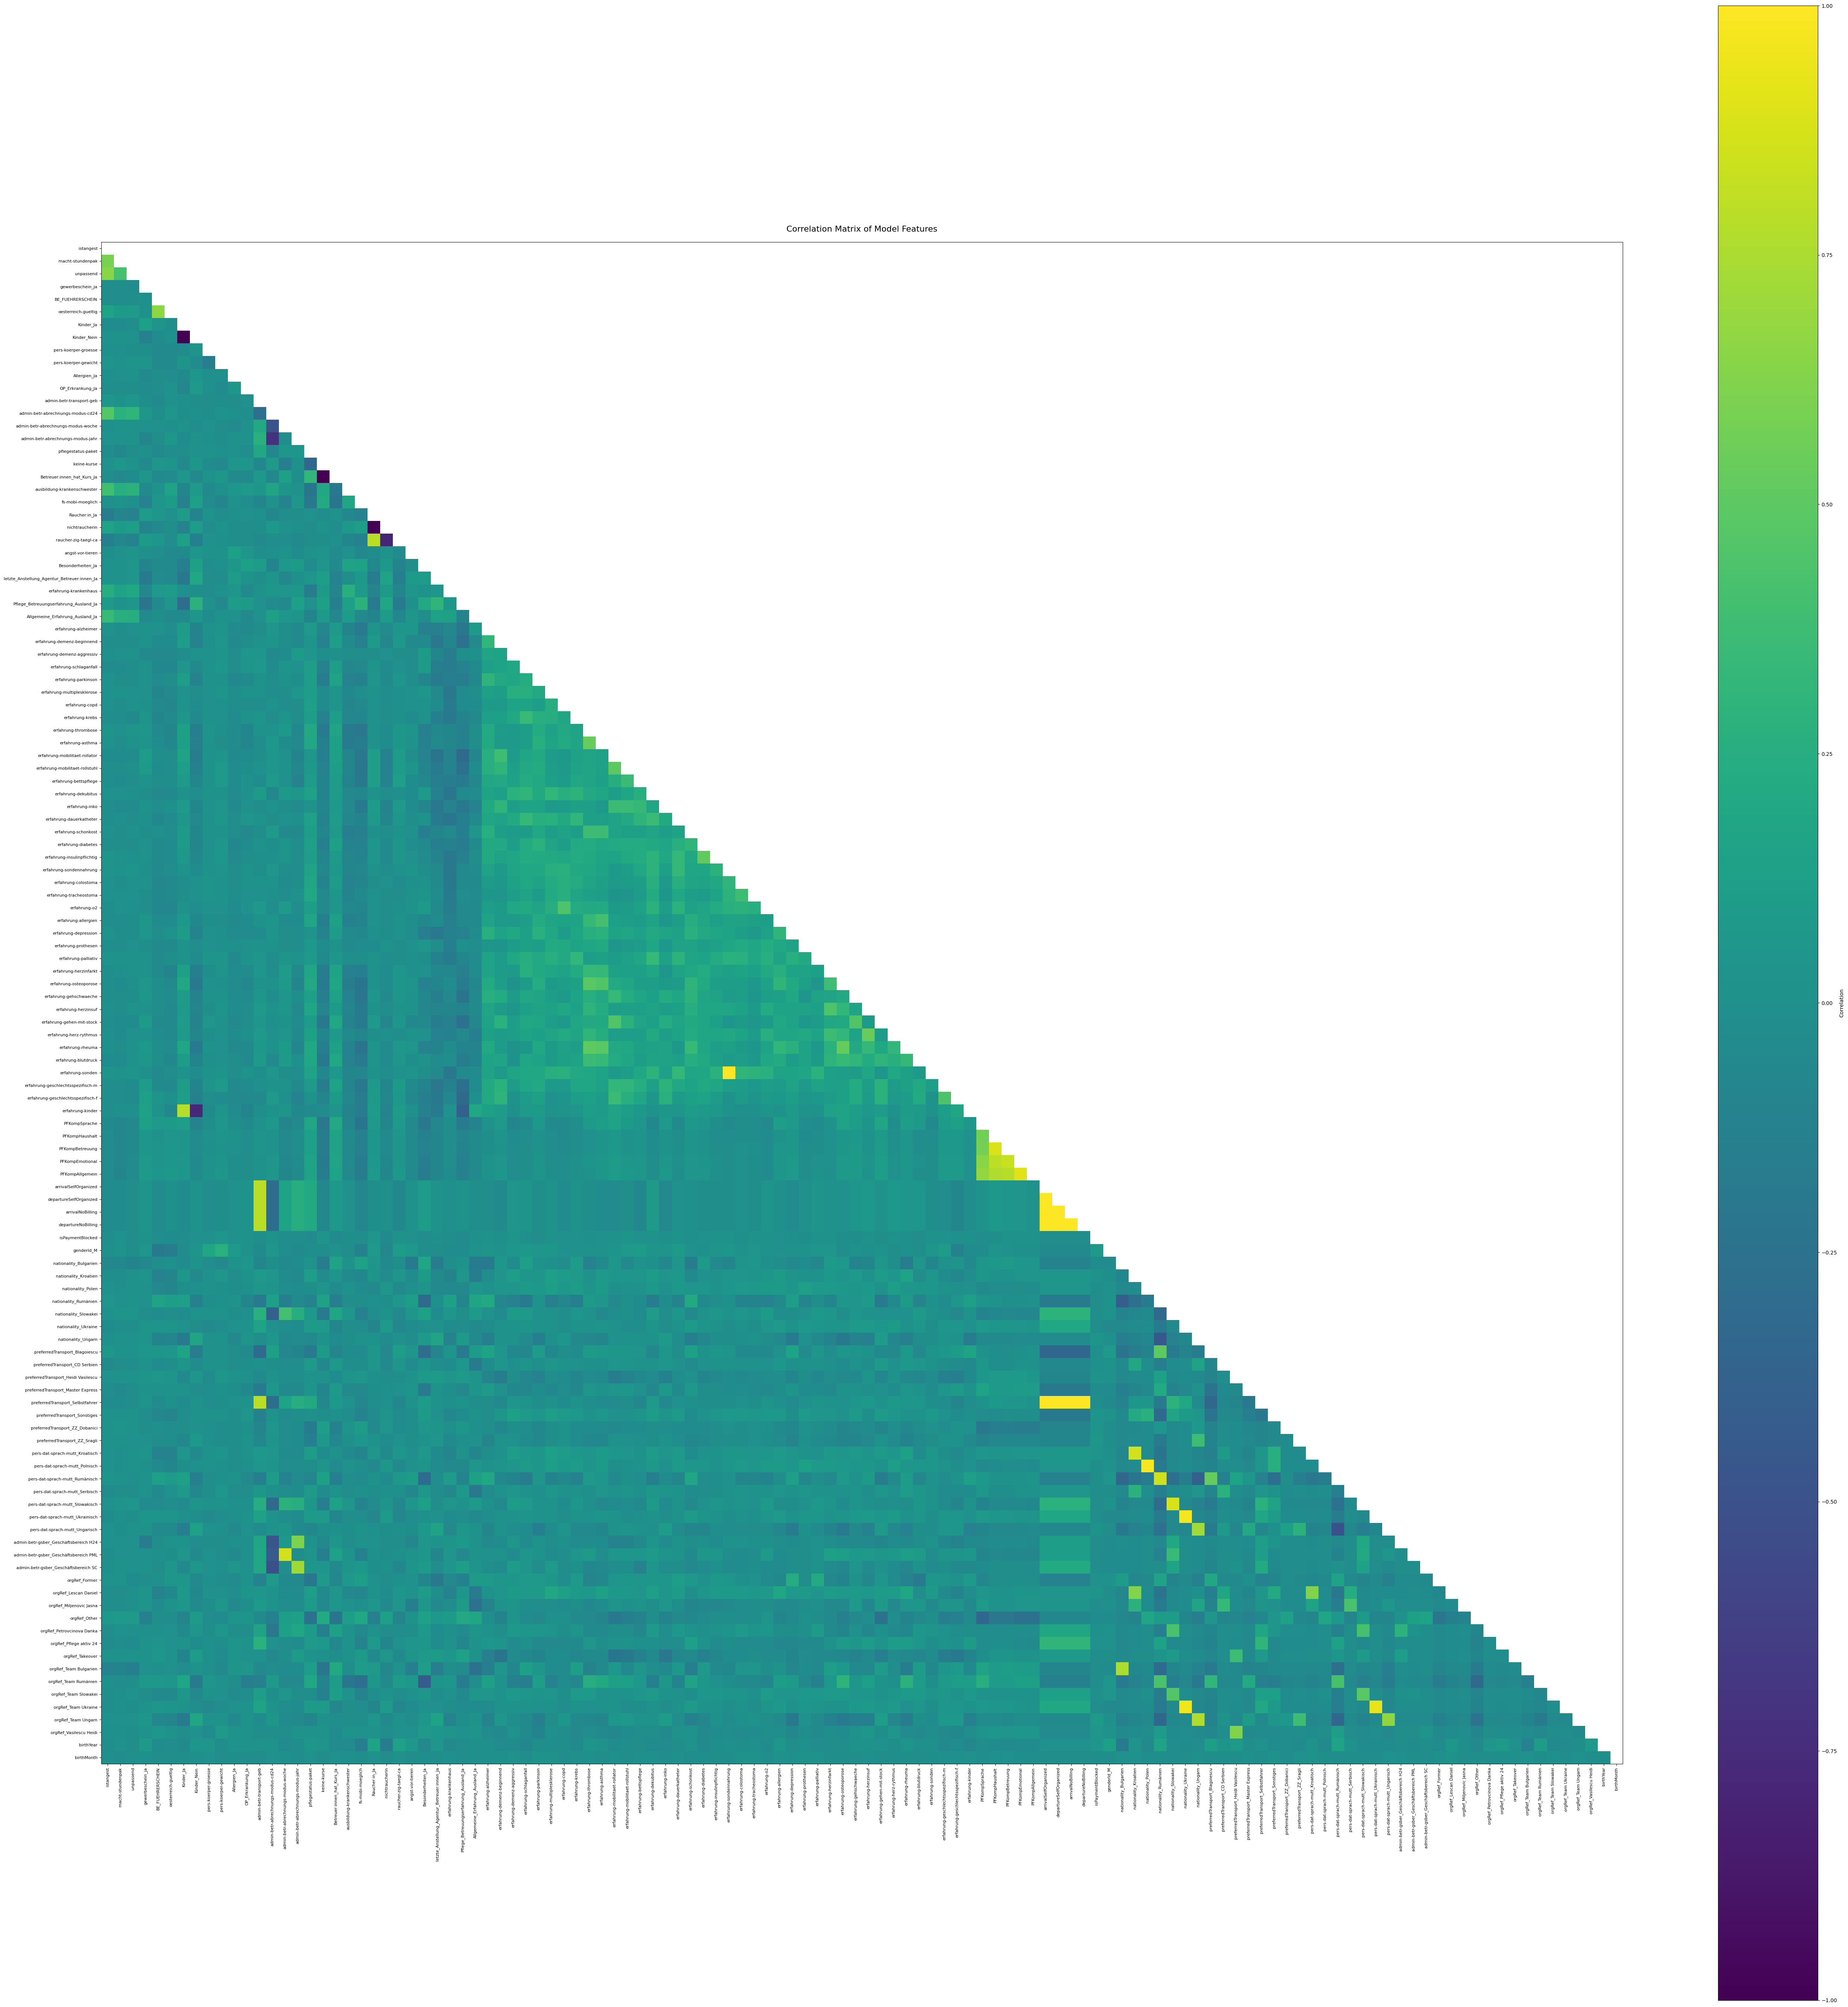

In [145]:
corr = df_final.corr(numeric_only=True)

# Hide upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Dynamic figure size
n_features = len(corr.columns)
figsize = max(12, n_features * 0.45)

fig, ax = plt.subplots(figsize=(figsize, figsize))

# Mask upper triangle
corr_masked = np.ma.masked_where(mask, corr.values)

im = ax.imshow(
    corr_masked,
    vmin=-1,
    vmax=1,
    aspect="equal"
)

fig.colorbar(im, ax=ax, label="Correlation")

ax.set_xticks(range(n_features))
ax.set_yticks(range(n_features))

ax.set_xticklabels(
    corr.columns,
    rotation=90,
    fontsize=8
)

ax.set_yticklabels(
    corr.columns,
    fontsize=8
)

ax.set_title(
    "Correlation Matrix of Model Features",
    fontsize=16,
    pad=20
)

plt.tight_layout()
plt.show()

In [146]:
corr = df_final.corr(numeric_only=True)

threshold = 0.8

strong_corr = corr.where(
    (corr.abs() >= threshold) & (corr.abs() < 1)
)

# Remove features that have no strong correlations
keep = strong_corr.notna().any()

strong_corr = strong_corr.loc[keep, keep]

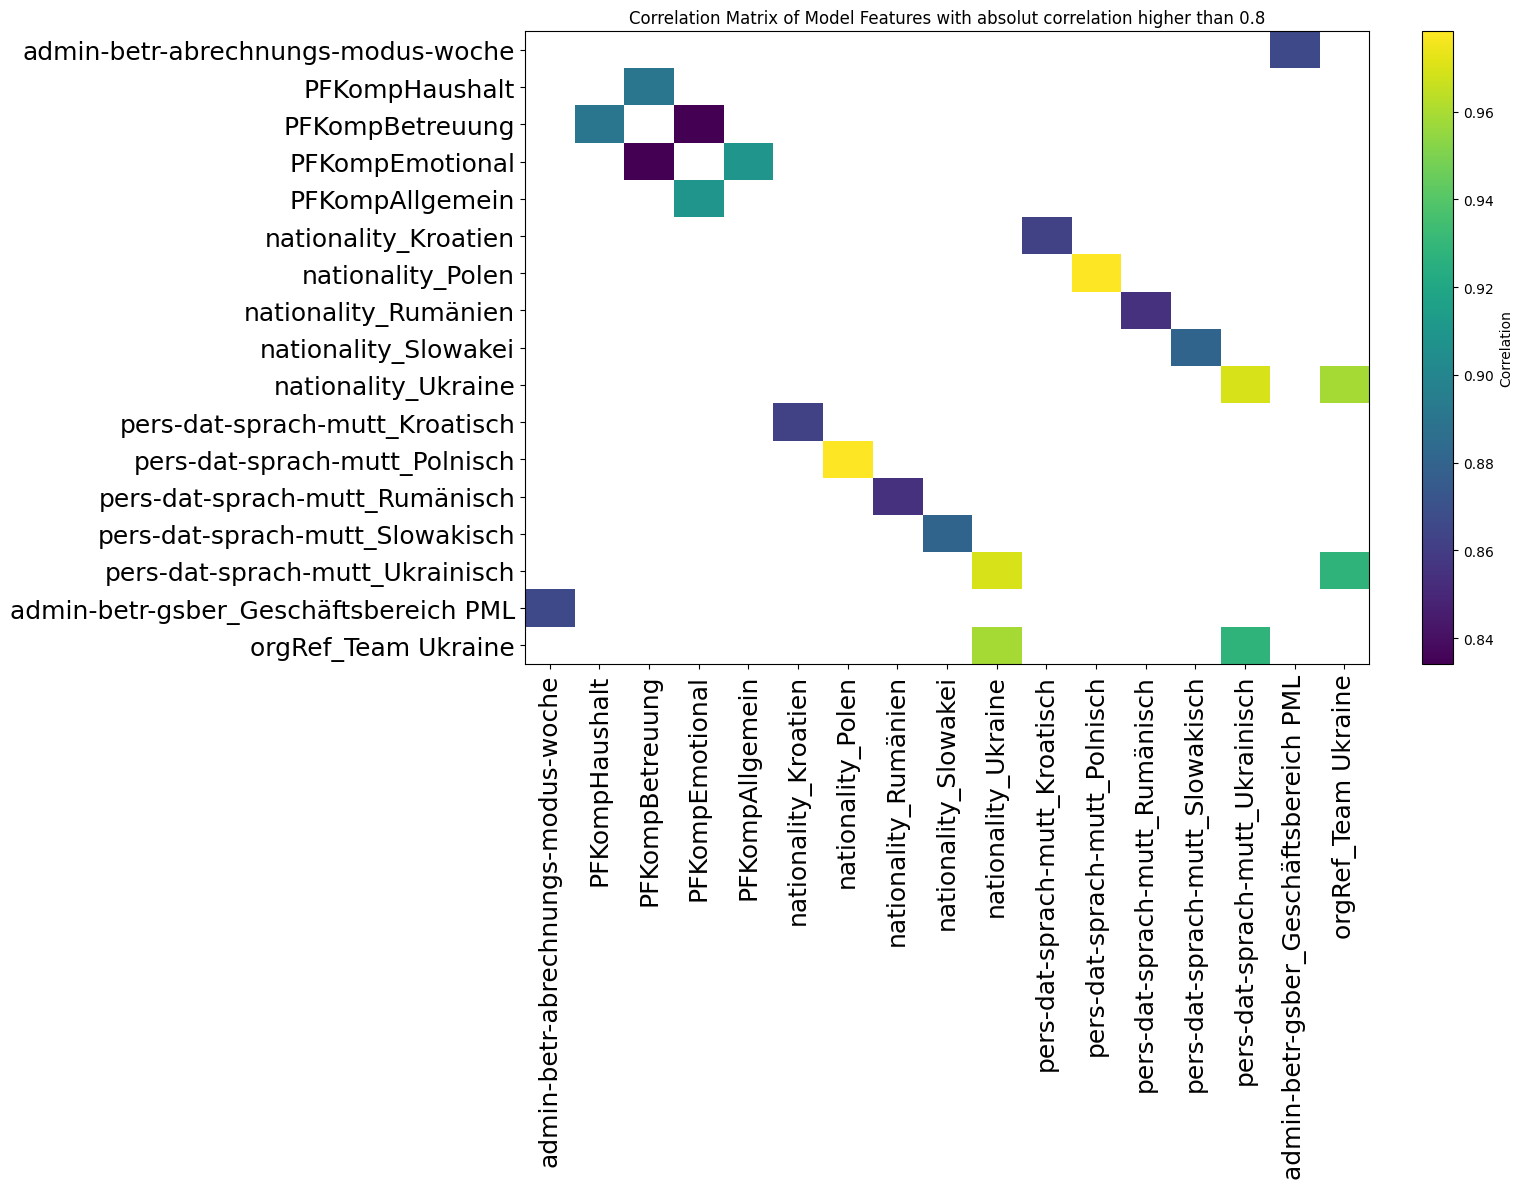

In [147]:
corr_matrix = strong_corr

plt.figure(figsize=(16, 12))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
	fontsize=18
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
	fontsize=18
)

plt.title("Correlation Matrix of Model Features with absolut correlation higher than 0.8")
plt.tight_layout()
plt.show()

In [148]:
colsToDrop = df_final.columns[
    df_final.columns.str.contains("pers-dat-sprach-mutt")
].tolist()

colsToDrop.append("orgRef_Team Ukraine")

df_caregivers = df_final.drop(columns=colsToDrop)

In [149]:
colsToCombine = [
    col for col in df_caregivers.columns
    if "PFKomp" in col and col != "PFKomp_mean"
]

colsToCombine


df_caregivers["PFKomp_mean"] = (
    df_caregivers[colsToCombine]
    .mean(axis=1)
    .round()
    .clip(1, 5)
)


df_toExport = df_caregivers.drop(columns=colsToCombine)

In [150]:
df_toExport.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6477 entries, 0 to 7370
Columns: 111 entries, id to PFKomp_mean
dtypes: bool(70), datetime64[ns](2), float64(5), int32(33), object(1)
memory usage: 1.7+ MB


In [151]:
df_toExport.to_csv("caregivers.csv",sep=";",index=False)